In [1]:
#imports
import re
from pathlib import Path
from collections import Counter

import joblib
import mne
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

In [2]:
#feature extraction helpers
def zero_mean_interval(sig_1s):
    return sig_1s - np.mean(sig_1s)


def get_zero_crossing_indices(sig):
    signs = np.sign(sig).astype(float)

    # replace exact zeros with previous sign (or +1 if first sample)
    for i in range(len(signs)):
        if signs[i] == 0:
            signs[i] = 1 if i == 0 else signs[i - 1]

    return np.where(np.diff(signs) != 0)[0]


def compute_x_features(epoch, sfreq):
    """
    Compute x = [x1, x2, x3] for one 30-second epoch.

    x1 = mean ZCP segment length
    x2 = std ZCP segment length
    x3 = sum over segments of (segment duration * absolute area)

    epoch: 1D numpy array of length 30 * sfreq
    """
    samples_per_sec = int(sfreq)
    assert len(epoch) == 30 * samples_per_sec, "Expected a 30-second epoch"

    all_segment_lengths = []
    x3_total = 0.0

    for sec in range(30):
        start = sec * samples_per_sec
        end = (sec + 1) * samples_per_sec
        seg_1s = zero_mean_interval(epoch[start:end])

        zc = get_zero_crossing_indices(seg_1s)

        if len(zc) < 2:
            continue

        for i in range(len(zc) - 1):
            e_i = zc[i]
            e_ip1 = zc[i + 1]

            seg_len_sec = (e_ip1 - e_i) / sfreq
            all_segment_lengths.append(seg_len_sec)

            area = np.sum(np.abs(seg_1s[e_i:e_ip1])) / sfreq
            x3_total += seg_len_sec * area

    if len(all_segment_lengths) == 0:
        return np.array([np.nan, np.nan, np.nan], dtype=float)

    x1 = np.mean(all_segment_lengths)
    x2 = np.std(all_segment_lengths)
    x3 = x3_total

    return np.array([x1, x2, x3], dtype=float)

In [3]:
# Binary target:
# 1 = SWS (stages 3 and 4)
# 0 = NSWS (W, 1, 2, R)
VALID_LABEL_MAP = {
    "Sleep stage W": 0,
    "Sleep stage 1": 0,
    "Sleep stage 2": 0,
    "Sleep stage 3": 1,
    "Sleep stage 4": 1,
    "Sleep stage R": 0,
}

IGNORE_LABELS = {
    "Movement time",
    "Sleep stage ?",
}

ANNOTATION_DESC_2_EVENT_ID = {
    "Sleep stage W": 1,
    "Sleep stage 1": 2,
    "Sleep stage 2": 3,
    "Sleep stage 3": 4,
    "Sleep stage 4": 5,
    "Sleep stage R": 6,
}

In [4]:
def pairing_key(filename: str) -> str:
    return filename[:7]


def match_sleep_edf_pairs(root_dir):
    root_dir = Path(root_dir)

    psg_files = sorted(root_dir.glob("*-PSG.edf"))
    hyp_files = sorted(root_dir.glob("*-Hypnogram.edf"))

    hyp_by_key = {}
    for hyp in hyp_files:
        hyp_by_key[pairing_key(hyp.name)] = hyp

    pairs = []
    for psg in psg_files:
        key = pairing_key(psg.name)
        hyp = hyp_by_key.get(key)
        if hyp is not None:
            pairs.append((psg, hyp, key))

    return pairs

In [5]:

def pick_eeg_channel(raw):
    preferred = ["EEG Fpz-Cz", "EEG Pz-Oz", "Fpz-Cz", "Pz-Oz"]
    for want in preferred:
        if want in raw.ch_names:
            return want

    # fallback: first EEG-looking channel
    for ch in raw.ch_names:
        if "EEG" in ch.upper() or "FPZ-CZ" in ch.upper() or "PZ-OZ" in ch.upper():
            return ch

    raise ValueError("No EEG channel found")


def read_sleep_edf_record(psg_path, hyp_path):
    raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
    annot = mne.read_annotations(hyp_path)
    raw.set_annotations(annot, emit_warning=False)

    chosen = pick_eeg_channel(raw)
    sfreq = int(raw.info["sfreq"])

    # create one event per 30s chunk inside each annotated stage segment
    events, event_id = mne.events_from_annotations(
        raw,
        event_id=ANNOTATION_DESC_2_EVENT_ID,
        chunk_duration=30.0,
        verbose=False,
    )

    if len(events) == 0:
        raise ValueError(f"No usable sleep-stage events found for {psg_path.name}")

    # extract 30-second epochs from chosen EEG channel only
    epochs = mne.Epochs(
        raw.copy().pick([chosen]),
        events=events,
        event_id=event_id,
        tmin=0.0,
        tmax=30.0 - 1.0 / sfreq,
        baseline=None,
        preload=True,
        verbose=False,
    )

    X_list = []
    y_list = []

    inv_event_id = {v: k for k, v in event_id.items()}

    epoch_data = epochs.get_data()[:, 0, :]  # shape: (n_epochs, n_samples)
    epoch_codes = epochs.events[:, 2]

    for sig, code in zip(epoch_data, epoch_codes):
        label_str = inv_event_id[code]

        if label_str in IGNORE_LABELS:
            continue
        if label_str not in VALID_LABEL_MAP:
            continue

        x = compute_x_features(sig, sfreq)
        if np.isnan(x).any():
            continue

        X_list.append(x)
        y_list.append(VALID_LABEL_MAP[label_str])

    if len(X_list) == 0:
        raise ValueError(f"No valid labeled epochs extracted from {psg_path.name}")

    return np.array(X_list), np.array(y_list), chosen, sfreq

In [8]:
#sanity checks
data_dir = Path("./sleep-edf-database-expanded")
pairs = match_sleep_edf_pairs(data_dir)

print("Number of matched pairs:", len(pairs))
print("First 5 pairs:")
for psg, hyp, key in pairs[:5]:
    print(key, "->", psg.name, "<->", hyp.name)

Number of matched pairs: 44
First 5 pairs:
ST7011J -> ST7011J0-PSG.edf <-> ST7011JP-Hypnogram.edf
ST7012J -> ST7012J0-PSG.edf <-> ST7012JP-Hypnogram.edf
ST7021J -> ST7021J0-PSG.edf <-> ST7021JM-Hypnogram.edf
ST7022J -> ST7022J0-PSG.edf <-> ST7022JM-Hypnogram.edf
ST7041J -> ST7041J0-PSG.edf <-> ST7041JO-Hypnogram.edf


In [7]:
X_one, y_one, ch_name, sfreq = read_sleep_edf_record(
    pairs[0][0],
    pairs[0][1],
)

print("Chosen EEG channel:", ch_name)
print("Sampling rate:", sfreq)
print("X_one shape:", X_one.shape)
print("y_one shape:", y_one.shape)
print("Class counts:", np.unique(y_one, return_counts=True))
print("First 5 feature rows:\n", X_one[:5])

/var/folders/nl/k9vvzpz57vj2dcsjwk1pfq780000gp/T/ipykernel_97559/2992557722.py:16: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/var/folders/nl/k9vvzpz57vj2dcsjwk1pfq780000gp/T/ipykernel_97559/2992557722.py:16: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)


Chosen EEG channel: EEG Fpz-Cz
Sampling rate: 100
X_one shape: (1092, 3)
y_one shape: (1092,)
Class counts: (array([0, 1]), array([956, 136]))
First 5 feature rows:
 [[2.66666667e-02 3.13571509e-02 6.46620839e-06]
 [3.35875217e-02 5.38254743e-02 6.26157059e-05]
 [4.40723982e-02 6.32897110e-02 4.13149266e-05]
 [3.97138047e-02 5.64531233e-02 4.38237901e-05]
 [4.16760829e-02 4.89937981e-02 2.00452009e-05]]


In [9]:
#build full dataset
def build_dataset(root_dir):
    pairs = match_sleep_edf_pairs(root_dir)

    X_all = []
    y_all = []
    groups_all = []

    for psg_path, hyp_path, record_key in pairs:
        try:
            X_rec, y_rec, ch_name, sfreq = read_sleep_edf_record(psg_path, hyp_path)

            X_all.append(X_rec)
            y_all.append(y_rec)
            groups_all.extend([record_key] * len(y_rec))

            print(f"{record_key}: {len(y_rec)} epochs | ch={ch_name} | sfreq={sfreq}")

        except Exception as e:
            print(f"Skipping {record_key}: {e}")

    if len(X_all) == 0:
        raise ValueError("No valid records were loaded.")

    X_all = np.vstack(X_all)
    y_all = np.concatenate(y_all)
    groups_all = np.array(groups_all)

    return X_all, y_all, groups_all

In [10]:
#actually build dataset, sanity checks
X, y, groups = build_dataset(data_dir)

print("Dataset shape:", X.shape)
print("Label shape:", y.shape)
print("Num records represented:", len(np.unique(groups)))
print("Positive class fraction (SWS):", y.mean())

print("Total samples:", X.shape[0])
print("Unique records:", len(np.unique(groups)))
print("Positive fraction:", y.mean())
print("Feature mins:", X.min(axis=0))
print("Feature maxs:", X.max(axis=0))

/var/folders/nl/k9vvzpz57vj2dcsjwk1pfq780000gp/T/ipykernel_97559/2992557722.py:16: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/var/folders/nl/k9vvzpz57vj2dcsjwk1pfq780000gp/T/ipykernel_97559/2992557722.py:16: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)


ST7011J: 1092 epochs | ch=EEG Fpz-Cz | sfreq=100


/var/folders/nl/k9vvzpz57vj2dcsjwk1pfq780000gp/T/ipykernel_97559/2992557722.py:16: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/var/folders/nl/k9vvzpz57vj2dcsjwk1pfq780000gp/T/ipykernel_97559/2992557722.py:16: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)


ST7012J: 1035 epochs | ch=EEG Fpz-Cz | sfreq=100


/var/folders/nl/k9vvzpz57vj2dcsjwk1pfq780000gp/T/ipykernel_97559/2992557722.py:16: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/var/folders/nl/k9vvzpz57vj2dcsjwk1pfq780000gp/T/ipykernel_97559/2992557722.py:16: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)


...

ST7222J: 950 epochs | ch=EEG Fpz-Cz | sfreq=100


/var/folders/nl/k9vvzpz57vj2dcsjwk1pfq780000gp/T/ipykernel_97559/2992557722.py:16: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/var/folders/nl/k9vvzpz57vj2dcsjwk1pfq780000gp/T/ipykernel_97559/2992557722.py:16: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)


ST7241J: 1014 epochs | ch=EEG Fpz-Cz | sfreq=100


/var/folders/nl/k9vvzpz57vj2dcsjwk1pfq780000gp/T/ipykernel_97559/2992557722.py:16: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/var/folders/nl/k9vvzpz57vj2dcsjwk1pfq780000gp/T/ipykernel_97559/2992557722.py:16: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)


ST7242J: 939 epochs | ch=EEG Fpz-Cz | sfreq=100
Dataset shape: (42615, 3)
Label shape: (42615,)
Num records represented: 44
Positive class fraction (SWS): 0.15053384958347998
Total samples: 42615
Unique records: 44
Positive fraction: 0.15053384958347998
Feature mins: [1.26554918e-02 0.00000000e+00 2.64058597e-07]
Feature maxs: [0.27       0.21338167 0.00055653]


In [11]:
#split by record, not by epoch
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("Train positive fraction:", y_train.mean())
print("Test positive fraction:", y_test.mean())

Train size: 34116
Test size: 8499
Train positive fraction: 0.1598077148551999
Test positive fraction: 0.11330744793505118


In [12]:
models = {
    "logreg": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        )),
    ]),

    "mlp": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(16,),
            activation="relu",
            max_iter=1000,
            random_state=42
        )),
    ]),

    "rf": RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        class_weight="balanced",
        random_state=42
    ),
}

In [13]:
results = {}

for name, model in models.items():
    print("=" * 60)
    print(f"Training {name}...")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    bal_acc = balanced_accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, digits=4)

    results[name] = {
        "model": model,
        "balanced_accuracy": bal_acc,
        "confusion_matrix": cm,
        "classification_report": report,
    }

    print("Balanced accuracy:", bal_acc)
    print("Confusion matrix:\n", cm)
    print(report)

Training logreg...
Balanced accuracy: 0.9371227867399514
Confusion matrix:
 [[6737  799]
 [  19  944]]
              precision    recall  f1-score   support

           0     0.9972    0.8940    0.9428      7536
           1     0.5416    0.9803    0.6977       963

    accuracy                         0.9038      8499
   macro avg     0.7694    0.9371    0.8202      8499
weighted avg     0.9456    0.9038    0.9150      8499

Training mlp...
Balanced accuracy: 0.9281829358228995
Confusion matrix:
 [[7197  339]
 [  95  868]]
              precision    recall  f1-score   support

           0     0.9870    0.9550    0.9707      7536
           1     0.7191    0.9013    0.8000       963

    accuracy                         0.9489      8499
   macro avg     0.8531    0.9282    0.8854      8499
weighted avg     0.9566    0.9489    0.9514      8499

Training rf...
Balanced accuracy: 0.9363813818282835
Confusion matrix:
 [[6718  818]
 [  18  945]]
              precision    recall  f1-score 

In [14]:
#compare models, save all
print("Model summary:")
for name, res in results.items():
    print(f"{name}: balanced_accuracy = {res['balanced_accuracy']:.4f}")

best_name = max(results, key=lambda k: results[k]["balanced_accuracy"])
best_model = results[best_name]["model"]

print("\nBest model by balanced accuracy:", best_name)

# Save all models
joblib.dump(results["logreg"]["model"], "sws_logreg.joblib")
joblib.dump(results["mlp"]["model"], "sws_mlp.joblib")
joblib.dump(results["rf"]["model"], "sws_rf.joblib")

# Also save the "best" one under a generic filename for convenience
joblib.dump(best_model, "sws_x_model_best.joblib")

print("Saved models:")
print("  sws_logreg.joblib")
print("  sws_mlp.joblib")
print("  sws_rf.joblib")
print("  sws_x_model_best.joblib")

Model summary:
logreg: balanced_accuracy = 0.9371
mlp: balanced_accuracy = 0.9282
rf: balanced_accuracy = 0.9364

Best model by balanced accuracy: logreg
Saved models:
  sws_logreg.joblib
  sws_mlp.joblib
  sws_rf.joblib
  sws_x_model_best.joblib


In [16]:
#sanity check all models:
saved_model_files = {
    "logreg": "sws_logreg.joblib",
    "mlp": "sws_mlp.joblib",
    "rf": "sws_rf.joblib",
    "best": "sws_x_model_best.joblib",
}

example_x = X_test[0].reshape(1, -1)
true_y = y_test[0]

print("Example feature row:", X_test[0])
print("True label:", true_y)
print()

for model_name, model_file in saved_model_files.items():
    loaded_model = joblib.load(model_file)

    pred = loaded_model.predict(example_x)[0]
    print(f"{model_name} predicted label: {pred}")

    if hasattr(loaded_model, "predict_proba"):
        proba = loaded_model.predict_proba(example_x)[0]
        print(f"{model_name} predicted probabilities: {proba}")

    print()

Example feature row: [3.70242215e-02 5.36243770e-02 2.03050280e-05]
True label: 0

logreg predicted label: 0
logreg predicted probabilities: [0.98922395 0.01077605]

mlp predicted label: 0
mlp predicted probabilities: [9.99914951e-01 8.50486877e-05]

rf predicted label: 0
rf predicted probabilities: [0.98466386 0.01533614]

best predicted label: 0
best predicted probabilities: [0.98922395 0.01077605]



In [17]:
saved_model_files = {
    "logreg": "sws_logreg.joblib",
    "mlp": "sws_mlp.joblib",
    "rf": "sws_rf.joblib",
    "best": "sws_x_model_best.joblib",
}

example_x = X_test[0].reshape(1, -1)
true_y = y_test[0]

print("Example feature row:", X_test[0])
print("True label:", true_y)
print()

for model_name, model_file in saved_model_files.items():
    loaded_model = joblib.load(model_file)

    pred = loaded_model.predict(example_x)[0]
    print(f"{model_name}:")
    print(f"  predicted label = {pred}")

    if hasattr(loaded_model, "predict_proba"):
        proba = loaded_model.predict_proba(example_x)[0]
        print(f"  P(non-SWS) = {proba[0]:.4f}")
        print(f"  P(SWS)     = {proba[1]:.4f}")

    print()

Example feature row: [3.70242215e-02 5.36243770e-02 2.03050280e-05]
True label: 0

logreg:
  predicted label = 0
  P(non-SWS) = 0.9892
  P(SWS)     = 0.0108

mlp:
  predicted label = 0
  P(non-SWS) = 0.9999
  P(SWS)     = 0.0001

rf:
  predicted label = 0
  P(non-SWS) = 0.9847
  P(SWS)     = 0.0153

best:
  predicted label = 0
  P(non-SWS) = 0.9892
  P(SWS)     = 0.0108



In [18]:
summary = {
    name: {
        "balanced_accuracy": res["balanced_accuracy"],
        "confusion_matrix": res["confusion_matrix"],
        "classification_report": res["classification_report"],
    }
    for name, res in results.items()
}

In [19]:
import json

with open("model_summary.json", "w") as f:
    json.dump(summary, f, indent=4, default=str)

print("Saved model_summary.json")

Saved model_summary.json


In [20]:
import joblib

joblib.dump(summary, "model_summary.joblib")
print("Saved model_summary.joblib")

Saved model_summary.joblib


In [21]:
with open("model_summary.txt", "w") as f:
    for name, res in summary.items():
        f.write(f"{name}\n")
        f.write(f"Balanced Accuracy: {res['balanced_accuracy']}\n")
        f.write(f"Confusion Matrix:\n{res['confusion_matrix']}\n")
        f.write(f"{res['classification_report']}\n")
        f.write("="*50 + "\n")

print("Saved model_summary.txt")

Saved model_summary.txt


/var/folders/nl/k9vvzpz57vj2dcsjwk1pfq780000gp/T/ipykernel_98514/1518219587.py:95: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(PSG_PATH, preload=True, verbose=False)
/var/folders/nl/k9vvzpz57vj2dcsjwk1pfq780000gp/T/ipykernel_98514/1518219587.py:95: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(PSG_PATH, preload=True, verbose=False)


Sampling rate: 100.0
Channels: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental', 'Marker']

Using first SWS epoch:
Stage: Sleep stage 3
Start time: 1830.0 sec

Computed x feature vector:
x1 = 0.06646103896103898
x2 = 0.08176309086312716
x3 = 67.77001867789781
x = [6.64610390e-02 8.17630909e-02 6.77700187e+01]

Model Prediction:
Raw class = 1
Predicted: SWS
Probabilities: [0. 1.]


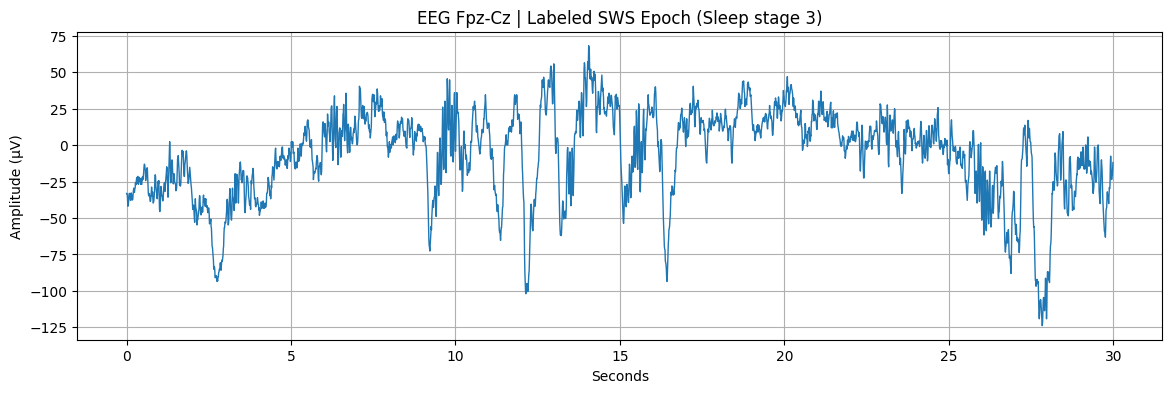

In [1]:
# a) visualizes fpz-cz channel data during epoch where slow wave sleep is classified (yes sws)
# b) computes x feature vector for that epoch
# c) runs inference (model prediction) using sws_mlp.joblib 
# ===============================
# JUPYTER CELL: Visualize SWS epoch + compute x + run model
# ===============================

import numpy as np
import matplotlib.pyplot as plt
import mne
import joblib

# -----------------------------
# USER SETTINGS
# -----------------------------
PSG_PATH = "sleep-edf-database-expanded/ST7012J0-PSG.edf"
HYPNOGRAM_PATH = "sleep-edf-database-expanded/ST7012JP-Hypnogram.edf"
MODEL_PATH = "sws_logreg.joblib"

CHANNEL_NAME = "EEG Fpz-Cz"
EPOCH_SEC = 30


# -----------------------------
# FEATURE FUNCTIONS
# -----------------------------
def zero_mean_interval(sig_1s):
    return sig_1s - np.mean(sig_1s)


def get_zero_crossing_indices(sig):
    signs = np.sign(sig).copy()

    for i in range(len(signs)):
        if signs[i] == 0:
            signs[i] = 1 if i == 0 else signs[i - 1]

    return np.where(np.diff(signs) != 0)[0]


def compute_x_features(epoch, sfreq):
    """
    epoch = 30-second 1D signal
    returns x = [x1, x2, x3]
    """

    samples_per_sec = int(round(sfreq))
    expected_len = EPOCH_SEC * samples_per_sec

    if len(epoch) != expected_len:
        raise ValueError(f"Expected {expected_len} samples, got {len(epoch)}")

    all_segment_lengths = []
    x3_total = 0.0

    for sec in range(EPOCH_SEC):

        start = sec * samples_per_sec
        end = (sec + 1) * samples_per_sec

        seg = epoch[start:end]
        seg = zero_mean_interval(seg)

        zc = get_zero_crossing_indices(seg)

        if len(zc) < 2:
            continue

        for i in range(len(zc) - 1):

            e0 = zc[i]
            e1 = zc[i + 1]

            seg_len_samples = e1 - e0
            seg_len_sec = seg_len_samples / sfreq

            all_segment_lengths.append(seg_len_sec)

            area = np.trapezoid(np.abs(seg[e0:e1 + 1]), dx=1 / sfreq)
            x3_total += seg_len_sec * area

    if len(all_segment_lengths) == 0:
        return np.array([0.0, 0.0, 0.0])

    x1 = np.mean(all_segment_lengths)
    x2 = np.std(all_segment_lengths)
    x3 = x3_total

    return np.array([x1, x2, x3])


# -----------------------------
# LOAD DATA
# -----------------------------
raw = mne.io.read_raw_edf(PSG_PATH, preload=True, verbose=False)
annot = mne.read_annotations(HYPNOGRAM_PATH)
raw.set_annotations(annot)

sfreq = raw.info["sfreq"]

print("Sampling rate:", sfreq)
print("Channels:", raw.ch_names)

# -----------------------------
# FIND FIRST SWS EPOCH
# -----------------------------
sws_labels = {"Sleep stage 3", "Sleep stage 4"}

sws_start = None
sws_desc = None

for onset, dur, desc in zip(
    raw.annotations.onset,
    raw.annotations.duration,
    raw.annotations.description
):
    if desc in sws_labels:
        sws_start = onset
        sws_desc = desc
        break

if sws_start is None:
    raise RuntimeError("No SWS epoch found.")

print(f"\nUsing first SWS epoch:")
print("Stage:", sws_desc)
print("Start time:", sws_start, "sec")


# -----------------------------
# EXTRACT CHANNEL DATA
# -----------------------------
ch_idx = raw.ch_names.index(CHANNEL_NAME)

start_sample = int(sws_start * sfreq)
end_sample = start_sample + int(EPOCH_SEC * sfreq)

epoch = raw.get_data(
    picks=[ch_idx],
    start=start_sample,
    stop=end_sample
)[0]

# convert volts -> microvolts
epoch = epoch * 1e6


# -----------------------------
# COMPUTE FEATURES
# -----------------------------
x = compute_x_features(epoch, sfreq)

print("\nComputed x feature vector:")
print("x1 =", x[0])
print("x2 =", x[1])
print("x3 =", x[2])
print("x =", x)


# -----------------------------
# LOAD MODEL + INFERENCE
# -----------------------------
model = joblib.load(MODEL_PATH)

pred = model.predict(x.reshape(1, -1))[0]

print("\nModel Prediction:")
print("Raw class =", pred)

if int(pred) == 1:
    print("Predicted: SWS")
else:
    print("Predicted: Not SWS")

if hasattr(model, "predict_proba"):
    probs = model.predict_proba(x.reshape(1, -1))[0]
    print("Probabilities:", probs)


# -----------------------------
# VISUALIZE EPOCH
# -----------------------------
t = np.arange(len(epoch)) / sfreq

plt.figure(figsize=(14,4))
plt.plot(t, epoch, linewidth=1)
plt.title(f"{CHANNEL_NAME} | Labeled SWS Epoch ({sws_desc})")
plt.xlabel("Seconds")
plt.ylabel("Amplitude (µV)")
plt.grid(True)
plt.show()

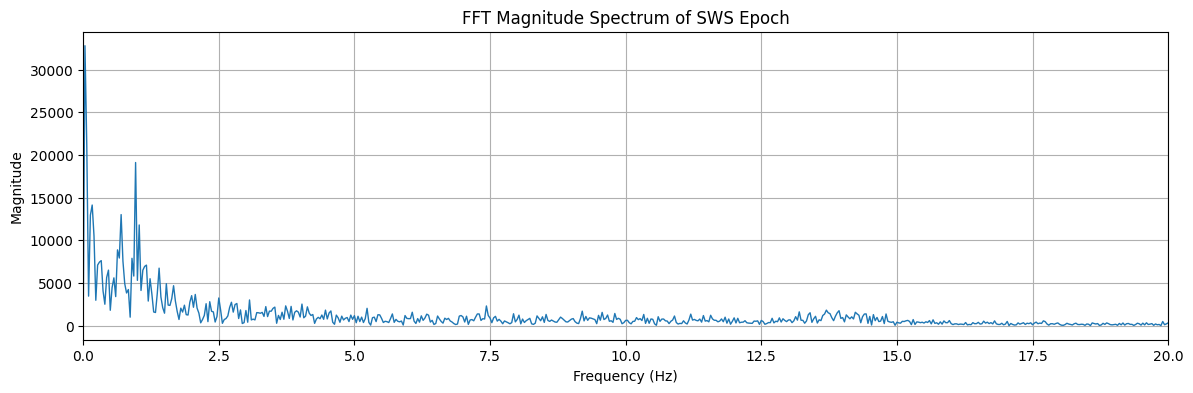

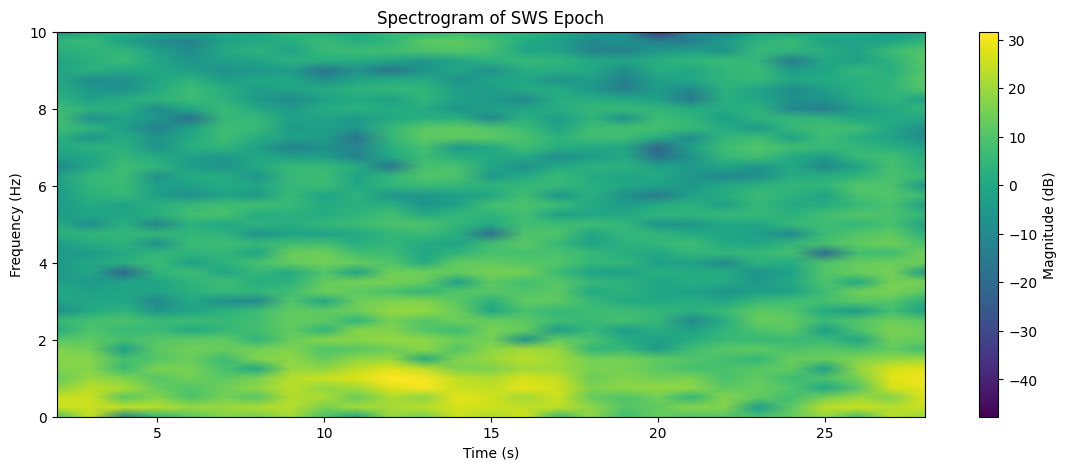

In [2]:
# ==========================================
# FFT + Spectrogram of SAME epoch variable
# Assumes:
# epoch  = your 30-second Fpz-Cz epoch in µV
# sfreq  = sampling rate
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# ------------------------------------------
# Remove DC offset first
# ------------------------------------------
sig = epoch - np.mean(epoch)

# ------------------------------------------
# FFT
# ------------------------------------------
N = len(sig)

X = np.fft.rfft(sig)
freqs = np.fft.rfftfreq(N, d=1/sfreq)

mag = np.abs(X)

# ------------------------------------------
# Plot FFT Magnitude
# ------------------------------------------
plt.figure(figsize=(14,4))
plt.plot(freqs, mag, linewidth=1)
plt.xlim(0, 20)   # focus on EEG relevant low freq
plt.title("FFT Magnitude Spectrum of SWS Epoch")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()


# ------------------------------------------
# Spectrogram
# ------------------------------------------
f, t, Sxx = spectrogram(
    sig,
    fs=sfreq,
    window='hann',
    nperseg=int(4*sfreq),      # 4-second window
    noverlap=int(3*sfreq),     # 75% overlap
    scaling='density',
    mode='magnitude'
)

# ------------------------------------------
# Plot Spectrogram
# ------------------------------------------
plt.figure(figsize=(14,5))
plt.pcolormesh(t, f, 20*np.log10(Sxx + 1e-12), shading='gouraud')
plt.ylim(0, 10)   # EEG low frequency focus
plt.colorbar(label="Magnitude (dB)")
plt.title("Spectrogram of SWS Epoch")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.show()

Number of detected positive peaks: 42
Estimated dominant frequency from time domain: 1.613 Hz
Estimated period: 0.620 s


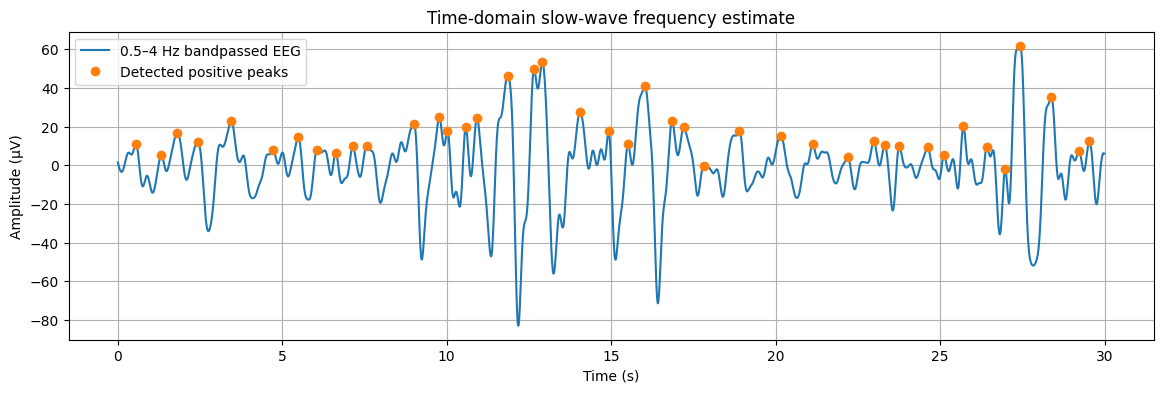

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# Assumes:
# epoch = 30s EEG epoch in µV
# sfreq = sampling rate

sig = epoch - np.mean(epoch)

# -----------------------------
# Bandpass 0.5–4 Hz
# -----------------------------
low = 0.5
high = 4.0

b, a = butter(
    N=4,
    Wn=[low, high],
    btype="bandpass",
    fs=sfreq
)

# filtfilt is zero-phase, good for offline visualization
# for embedded real-time, use lfilter/SOS/IIR instead
bp = filtfilt(b, a, sig)

# -----------------------------
# Time-domain frequency estimate from peaks
# -----------------------------
# Enforce minimum distance between peaks.
# For max 4 Hz, period = 0.25s, so half-cycle-ish spacing matters.
# For positive peaks, use min distance around 0.25s.
min_peak_distance = int(0.25 * sfreq)

peaks, props = find_peaks(
    bp,
    distance=min_peak_distance,
    prominence=np.std(bp) * 0.4
)

peak_times = peaks / sfreq

if len(peak_times) >= 2:
    periods = np.diff(peak_times)
    dominant_period = np.median(periods)
    dominant_freq = 1.0 / dominant_period
else:
    dominant_period = None
    dominant_freq = None

print("Number of detected positive peaks:", len(peaks))

if dominant_freq is not None:
    print(f"Estimated dominant frequency from time domain: {dominant_freq:.3f} Hz")
    print(f"Estimated period: {dominant_period:.3f} s")
else:
    print("Not enough peaks detected to estimate frequency.")

# -----------------------------
# Plot filtered signal and peaks
# -----------------------------
t = np.arange(len(bp)) / sfreq

plt.figure(figsize=(14, 4))
plt.plot(t, bp, label="0.5–4 Hz bandpassed EEG")
plt.plot(peak_times, bp[peaks], "o", label="Detected positive peaks")
plt.title("Time-domain slow-wave frequency estimate")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.grid(True)
plt.legend()
plt.show()

Using estimated frequency: 1.613 Hz
Using estimated period: 0.620 s
Detected troughs: 39
Predicted stimulation peaks: 38


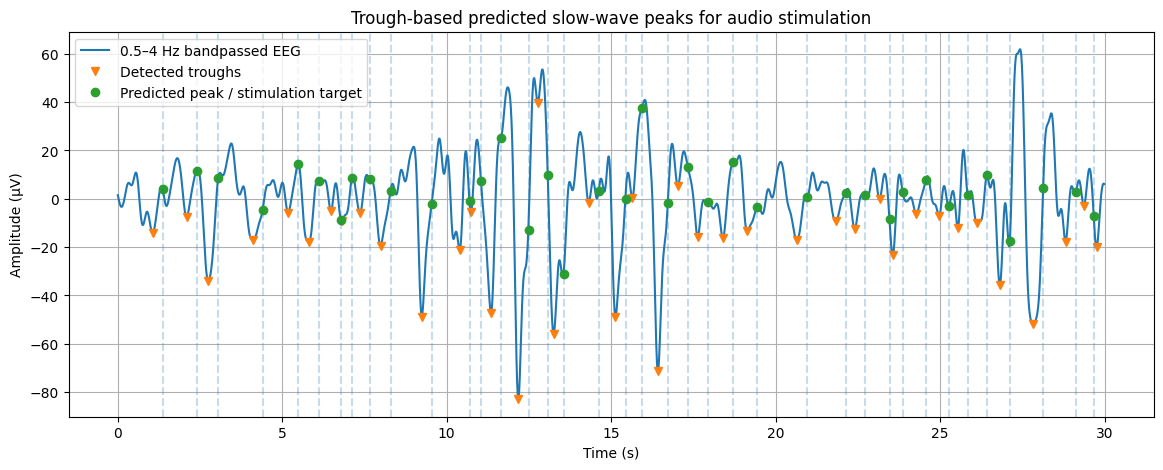

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# -----------------------------
# Use same epoch as "next epoch"
# -----------------------------
next_epoch = epoch.copy()
sig = next_epoch - np.mean(next_epoch)

# -----------------------------
# Bandpass 0.5–4 Hz
# -----------------------------
b, a = butter(
    N=4,
    Wn=[0.5, 4.0],
    btype="bandpass",
    fs=sfreq
)

bp = filtfilt(b, a, sig)

# -----------------------------
# Use previously estimated frequency/period
# -----------------------------
estimated_freq = 1.613
estimated_period = 1 / estimated_freq

print(f"Using estimated frequency: {estimated_freq:.3f} Hz")
print(f"Using estimated period: {estimated_period:.3f} s")

# -----------------------------
# Detect troughs
# -----------------------------
# Troughs are peaks of the negative signal
min_trough_distance = int(0.5 * estimated_period * sfreq)

troughs, trough_props = find_peaks(
    -bp,
    distance=min_trough_distance,
    prominence=np.std(bp) * 0.5
)

trough_times = troughs / sfreq

# -----------------------------
# Predict next positive peaks
# from trough + half period
# -----------------------------
predicted_peak_times = trough_times + estimated_period / 2
predicted_peak_samples = (predicted_peak_times * sfreq).astype(int)

# Keep only predictions inside epoch
valid = predicted_peak_samples < len(bp)

predicted_peak_times = predicted_peak_times[valid]
predicted_peak_samples = predicted_peak_samples[valid]

print("Detected troughs:", len(troughs))
print("Predicted stimulation peaks:", len(predicted_peak_samples))

# -----------------------------
# Plot
# -----------------------------
t = np.arange(len(bp)) / sfreq

plt.figure(figsize=(14, 5))

plt.plot(t, bp, label="0.5–4 Hz bandpassed EEG")

plt.plot(
    trough_times,
    bp[troughs],
    "v",
    label="Detected troughs"
)

plt.plot(
    predicted_peak_times,
    bp[predicted_peak_samples],
    "o",
    label="Predicted peak / stimulation target"
)

for pt in predicted_peak_times:
    plt.axvline(pt, linestyle="--", alpha=0.25)

plt.title("Trough-based predicted slow-wave peaks for audio stimulation")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.grid(True)
plt.legend()
plt.show()

Using estimated slow-wave frequency: 1.613 Hz
Using estimated period: 0.620 s
Half-period delay after trough: 0.310 s

Next epoch starts at 1860.00 sec
Detected troughs in next epoch: 44
Predicted stimulation peaks in next epoch: 44


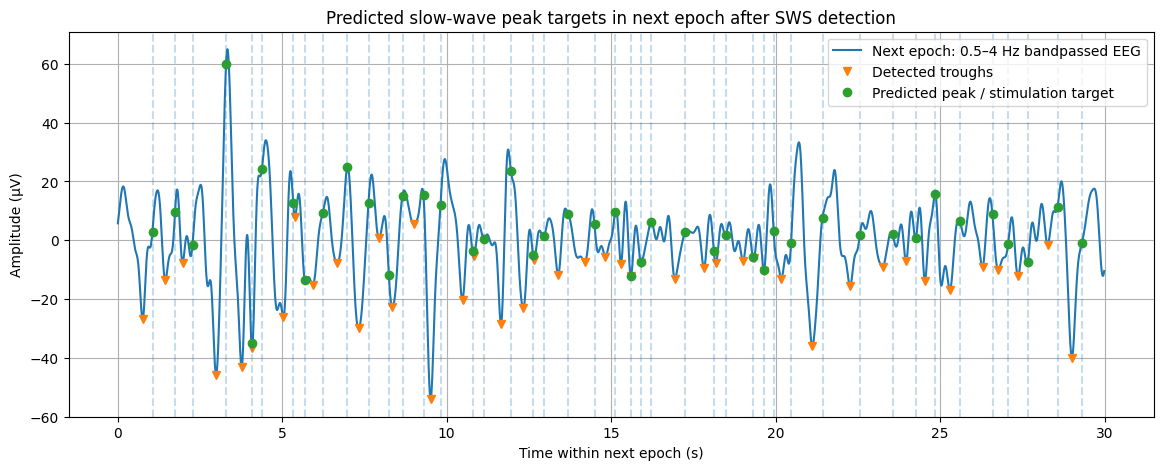

In [5]:
# ===============================
# NEXT EPOCH: trough detection + predicted peak markers
# ===============================

from scipy.signal import butter, filtfilt, find_peaks
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Use slow-wave frequency/period estimated from SWS epoch
# -----------------------------
estimated_freq = 1.613
estimated_period = 1 / estimated_freq

print(f"Using estimated slow-wave frequency: {estimated_freq:.3f} Hz")
print(f"Using estimated period: {estimated_period:.3f} s")
print(f"Half-period delay after trough: {estimated_period/2:.3f} s")

# -----------------------------
# Extract immediate next 30-second epoch
# -----------------------------
next_epoch_start = sws_start + EPOCH_SEC
next_start_sample = int(round(next_epoch_start * sfreq))
next_end_sample = next_start_sample + int(EPOCH_SEC * sfreq)

next_epoch = raw.get_data(
    picks=[ch_idx],
    start=next_start_sample,
    stop=next_end_sample
)[0] * 1e6  # volts -> µV

print(f"\nNext epoch starts at {next_epoch_start:.2f} sec")

# -----------------------------
# Bandpass 0.5–4 Hz
# -----------------------------
sig = next_epoch - np.mean(next_epoch)

b, a = butter(
    N=4,
    Wn=[0.5, 4.0],
    btype="bandpass",
    fs=sfreq
)

bp_next = filtfilt(b, a, sig)

# -----------------------------
# Detect troughs
# -----------------------------
min_trough_distance = int(0.5 * estimated_period * sfreq)

troughs, trough_props = find_peaks(
    -bp_next,
    distance=min_trough_distance,
    prominence=np.std(bp_next) * 0.5
)

trough_times = troughs / sfreq

# -----------------------------
# Predict next positive peaks
# trough + half period
# -----------------------------
predicted_peak_times = trough_times + estimated_period / 2
predicted_peak_samples = (predicted_peak_times * sfreq).astype(int)

valid = predicted_peak_samples < len(bp_next)

predicted_peak_times = predicted_peak_times[valid]
predicted_peak_samples = predicted_peak_samples[valid]

print("Detected troughs in next epoch:", len(troughs))
print("Predicted stimulation peaks in next epoch:", len(predicted_peak_samples))

# -----------------------------
# Plot next epoch with troughs + predicted peaks
# -----------------------------
t_next = np.arange(len(next_epoch)) / sfreq

plt.figure(figsize=(14, 5))
plt.plot(t_next, bp_next, label="Next epoch: 0.5–4 Hz bandpassed EEG")

plt.plot(
    trough_times,
    bp_next[troughs],
    "v",
    label="Detected troughs"
)

plt.plot(
    predicted_peak_times,
    bp_next[predicted_peak_samples],
    "o",
    label="Predicted peak / stimulation target"
)

for pt in predicted_peak_times:
    plt.axvline(pt, linestyle="--", alpha=0.25)

plt.title(f"Predicted slow-wave peak targets in next epoch after SWS detection")
plt.xlabel("Time within next epoch (s)")
plt.ylabel("Amplitude (µV)")
plt.grid(True)
plt.legend()
plt.show()

A) SWS epoch frequency estimate
Detected positive peaks: 36
Estimated dominant frequency: 1.250 Hz
Estimated period: 0.800 s


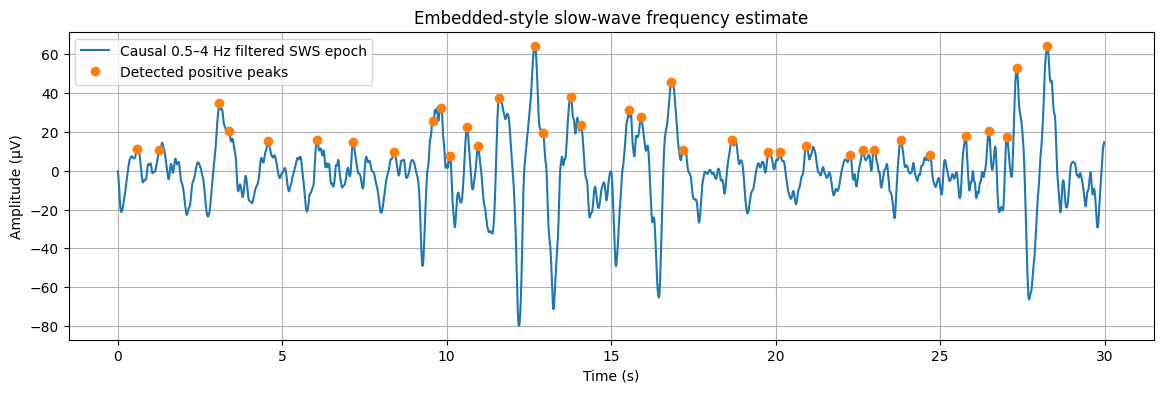


B) Next epoch stimulation prediction
Detected troughs: 35
Predicted stimulation peaks: 35
Half-period delay: 0.400 s
Half-period delay in samples: 40 samples


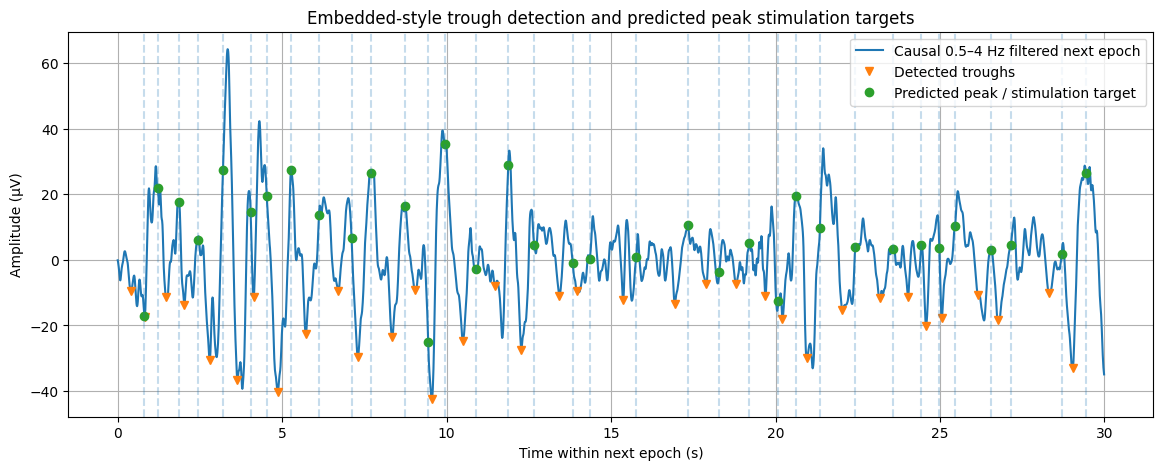

In [7]:
#mirroring embedded implementation:
# ============================================================
# EMBEDDED-STYLE SLOW WAVE PROCESSING
# No scipy butter/filtfilt/find_peaks.
# Uses causal biquad filters + manual peak/trough detection.
#
# Assumes:
# epoch      = detected SWS epoch in µV
# next_epoch = immediate next epoch in µV
# sfreq      = sample rate, probably 100 or 250
# ============================================================

import math
import matplotlib.pyplot as plt

FS = float(sfreq)

# -----------------------------
# Biquad filter implementation
# -----------------------------
class Biquad:
    def __init__(self, b0, b1, b2, a1, a2):
        self.b0 = b0
        self.b1 = b1
        self.b2 = b2
        self.a1 = a1
        self.a2 = a2

        self.x1 = 0.0
        self.x2 = 0.0
        self.y1 = 0.0
        self.y2 = 0.0

    def process(self, x):
        y = (
            self.b0 * x
            + self.b1 * self.x1
            + self.b2 * self.x2
            - self.a1 * self.y1
            - self.a2 * self.y2
        )

        self.x2 = self.x1
        self.x1 = x
        self.y2 = self.y1
        self.y1 = y

        return y


def make_lowpass(fc, fs, Q=0.707):
    w0 = 2.0 * math.pi * fc / fs
    cosw0 = math.cos(w0)
    sinw0 = math.sin(w0)
    alpha = sinw0 / (2.0 * Q)

    b0 = (1.0 - cosw0) / 2.0
    b1 = 1.0 - cosw0
    b2 = (1.0 - cosw0) / 2.0
    a0 = 1.0 + alpha
    a1 = -2.0 * cosw0
    a2 = 1.0 - alpha

    return Biquad(b0/a0, b1/a0, b2/a0, a1/a0, a2/a0)


def make_highpass(fc, fs, Q=0.707):
    w0 = 2.0 * math.pi * fc / fs
    cosw0 = math.cos(w0)
    sinw0 = math.sin(w0)
    alpha = sinw0 / (2.0 * Q)

    b0 = (1.0 + cosw0) / 2.0
    b1 = -(1.0 + cosw0)
    b2 = (1.0 + cosw0) / 2.0
    a0 = 1.0 + alpha
    a1 = -2.0 * cosw0
    a2 = 1.0 - alpha

    return Biquad(b0/a0, b1/a0, b2/a0, a1/a0, a2/a0)


def bandpass_0p5_4hz_causal(samples, fs):
    """
    Embedded-style causal bandpass:
    highpass 0.5 Hz then lowpass 4 Hz.
    """
    hp = make_highpass(0.5, fs)
    lp = make_lowpass(4.0, fs)

    out = []
    for x in samples:
        y = hp.process(float(x))
        y = lp.process(y)
        out.append(y)

    return out


# -----------------------------
# Manual helper functions
# -----------------------------
def mean_list(x):
    return sum(x) / len(x)


def std_list(x):
    mu = mean_list(x)
    return math.sqrt(sum((v - mu) ** 2 for v in x) / len(x))


def median_list(x):
    x_sorted = sorted(x)
    n = len(x_sorted)

    if n == 0:
        return None

    mid = n // 2

    if n % 2 == 1:
        return x_sorted[mid]
    else:
        return 0.5 * (x_sorted[mid - 1] + x_sorted[mid])


def remove_mean(samples):
    mu = mean_list(samples)
    return [float(x) - mu for x in samples]


# -----------------------------
# Manual positive peak detection
# -----------------------------
def detect_positive_peaks(samples, fs, min_distance_sec, threshold):
    peaks = []
    last_peak = -10**9
    min_distance_samples = int(min_distance_sec * fs)

    for i in range(1, len(samples) - 1):
        is_local_max = samples[i] > samples[i - 1] and samples[i] >= samples[i + 1]
        far_enough = (i - last_peak) >= min_distance_samples
        large_enough = samples[i] > threshold

        if is_local_max and far_enough and large_enough:
            peaks.append(i)
            last_peak = i

    return peaks


# -----------------------------
# Manual trough detection
# -----------------------------
def detect_troughs(samples, fs, min_distance_sec, threshold):
    troughs = []
    last_trough = -10**9
    min_distance_samples = int(min_distance_sec * fs)

    for i in range(1, len(samples) - 1):
        is_local_min = samples[i] < samples[i - 1] and samples[i] <= samples[i + 1]
        far_enough = (i - last_trough) >= min_distance_samples
        deep_enough = samples[i] < -threshold

        if is_local_min and far_enough and deep_enough:
            troughs.append(i)
            last_trough = i

    return troughs


# ============================================================
# A) Estimate slow-wave frequency from SWS-detected epoch
# ============================================================

sws_samples = remove_mean(list(epoch))

bp_sws = bandpass_0p5_4hz_causal(sws_samples, FS)

amp_threshold = 0.4 * std_list(bp_sws)
min_peak_distance_sec = 0.25

peaks = detect_positive_peaks(
    bp_sws,
    fs=FS,
    min_distance_sec=min_peak_distance_sec,
    threshold=amp_threshold
)

peak_times = [p / FS for p in peaks]

periods = []
for i in range(1, len(peak_times)):
    periods.append(peak_times[i] - peak_times[i - 1])

dominant_period = median_list(periods)

if dominant_period is not None:
    dominant_freq = 1.0 / dominant_period
else:
    dominant_freq = None

print("A) SWS epoch frequency estimate")
print("Detected positive peaks:", len(peaks))

if dominant_freq is not None:
    print(f"Estimated dominant frequency: {dominant_freq:.3f} Hz")
    print(f"Estimated period: {dominant_period:.3f} s")
else:
    print("Not enough peaks detected.")


# Plot SWS filtered signal + peaks
t_sws = [i / FS for i in range(len(bp_sws))]

plt.figure(figsize=(14, 4))
plt.plot(t_sws, bp_sws, label="Causal 0.5–4 Hz filtered SWS epoch")
plt.plot(peak_times, [bp_sws[p] for p in peaks], "o", label="Detected positive peaks")
plt.title("Embedded-style slow-wave frequency estimate")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# B) Use frequency to detect troughs in next epoch and predict peaks
# ============================================================

if dominant_period is None:
    raise RuntimeError("Need dominant_period before predicting stimulation peaks.")

next_samples = remove_mean(list(next_epoch))

bp_next = bandpass_0p5_4hz_causal(next_samples, FS)

trough_threshold = 0.5 * std_list(bp_next)

# Avoid detecting multiple troughs inside same slow wave
min_trough_distance_sec = 0.5 * dominant_period

troughs = detect_troughs(
    bp_next,
    fs=FS,
    min_distance_sec=min_trough_distance_sec,
    threshold=trough_threshold
)

trough_times = [tr / FS for tr in troughs]

# Predict next positive peak after trough
half_period_samples = int((dominant_period / 2.0) * FS)

predicted_peak_samples = []
for tr in troughs:
    pred = tr + half_period_samples
    if pred < len(bp_next):
        predicted_peak_samples.append(pred)

predicted_peak_times = [p / FS for p in predicted_peak_samples]

print("\nB) Next epoch stimulation prediction")
print("Detected troughs:", len(troughs))
print("Predicted stimulation peaks:", len(predicted_peak_samples))
print(f"Half-period delay: {dominant_period/2.0:.3f} s")
print(f"Half-period delay in samples: {half_period_samples} samples")


# Plot next epoch filtered signal + troughs + predicted peaks
t_next = [i / FS for i in range(len(bp_next))]

plt.figure(figsize=(14, 5))
plt.plot(t_next, bp_next, label="Causal 0.5–4 Hz filtered next epoch")

plt.plot(
    trough_times,
    [bp_next[tr] for tr in troughs],
    "v",
    label="Detected troughs"
)

plt.plot(
    predicted_peak_times,
    [bp_next[p] for p in predicted_peak_samples],
    "o",
    label="Predicted peak / stimulation target"
)

for pt in predicted_peak_times:
    plt.axvline(pt, linestyle="--", alpha=0.25)

plt.title("Embedded-style trough detection and predicted peak stimulation targets")
plt.xlabel("Time within next epoch (s)")
plt.ylabel("Amplitude (µV)")
plt.grid(True)
plt.legend()
plt.show()